# Fase 3: Análisis Integral de Resultados (Consolidado)

Este notebook unifica todos los análisis de la Fase 3, utilizando los datos generados por el pipeline CLI.

### Contenido:
1. **Estructura Global**: Matriz de Similitud entre todas las ventanas temporales.
2. **Dinámica de Complejidad**: Evolución de la dimensionalidad intrínseca (k).
3. **Deriva Semántica**: Estabilidad del subespacio y desplazamiento del centroide.
4. **Proyecciones Híbridas (Granular)**: Análisis detallado de significado frente a anclajes ortogonalizados (Lowdin).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = '../data'
results_path = os.path.join(DATA_DIR, 'phase3_results.parquet')
sim_matrix_path = os.path.join(DATA_DIR, 'phase3_sim_matrix.csv')

if os.path.exists(results_path):
    df = pd.read_parquet(results_path)
    print(f"Resultados cargados: {len(df)} ventanas.")
else:
    print("ERROR: Resultados principales no encontrados.")

if os.path.exists(sim_matrix_path):
    sim_df = pd.read_csv(sim_matrix_path, index_col=0)
    print(f"Matriz de Similitud cargada: {sim_df.shape}")
else:
    print("WARNING: Matriz de similitud no encontrada.")

Resultados cargados: 11 ventanas.
Matriz de Similitud cargada: (11, 11)


## 1. Estructura Global (Matriz de Similitud)
Visualización de la coherencia global del discurso. Bloques diagonales indican periodos estables.

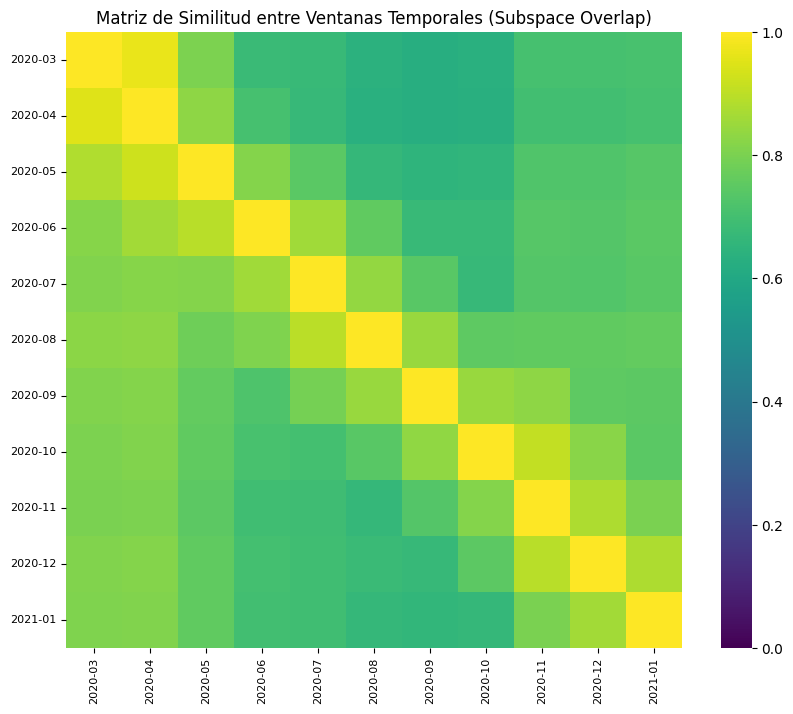

In [2]:
if 'sim_df' in locals():
    plt.figure(figsize=(10, 8))
    sns.heatmap(sim_df, cmap='viridis', square=True, vmin=0, vmax=1)
    plt.title("Matriz de Similitud entre Ventanas Temporales (Subspace Overlap)")
    plt.xticks(rotation=90, fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.show()

## 2. Dinámica de Complejidad y Estabilidad
¿Cómo cambia la riqueza del discurso (K) y cuánto cambia el tema (Drift)?

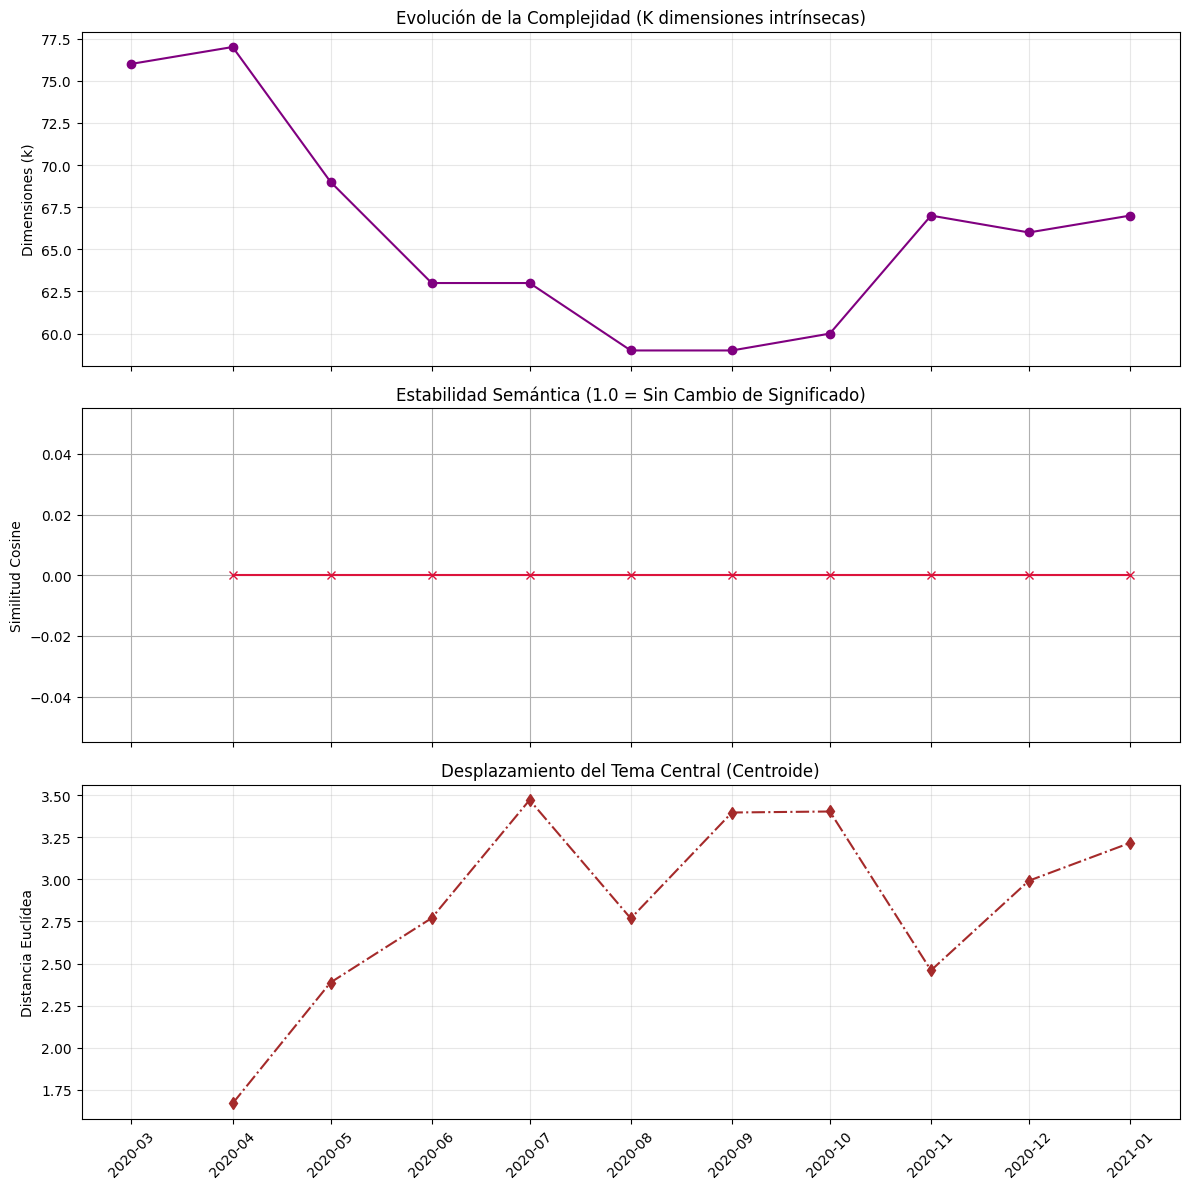

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# K Evolution
if 'intrinsic_dimension_k' in df.columns:
    axes[0].plot(df['date'], df['intrinsic_dimension_k'], marker='o', color='purple', linestyle='-')
    axes[0].set_title("Evolución de la Complejidad (K dimensiones intrínsecas)")
    axes[0].set_ylabel("Dimensiones (k)")
    axes[0].grid(True, alpha=0.3)

# Subspace Drift
axes[1].plot(df['date'], df['similarity'], marker='x', color='crimson', label='Estabilidad (Subespacio)')
axes[1].set_title("Estabilidad Semántica (1.0 = Sin Cambio de Significado)")
axes[1].set_ylabel("Similitud Cosine")
axes[1].grid(True)

# Centroid Drift
if 'centroid_drift' in df.columns:
    axes[2].plot(df['date'], df['centroid_drift'], marker='d', color='brown', linestyle='-.')
    axes[2].set_title("Desplazamiento del Tema Central (Centroide)")
    axes[2].set_ylabel("Distancia Euclídea")
    axes[2].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

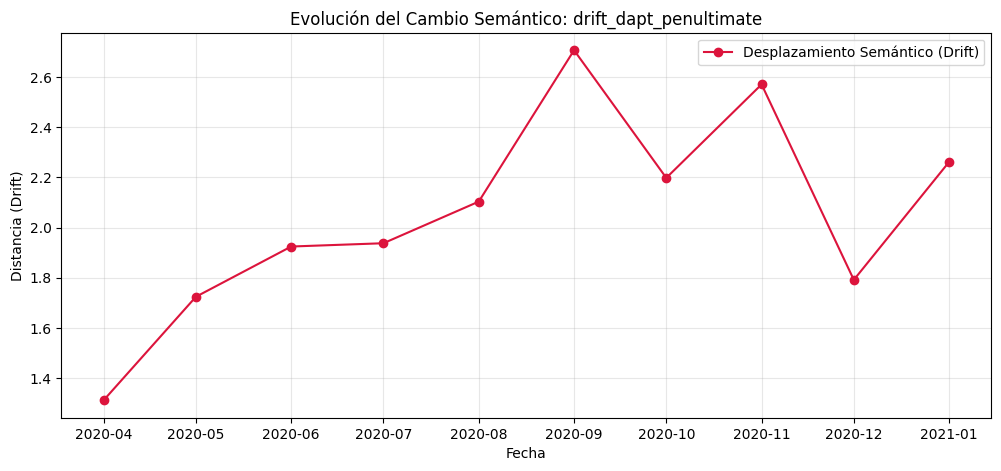

Interpretación: Picos altos = El significado de 'Salud Mental' cambió drásticamente ese mes.


In [6]:
# --- CORRECCIÓN DEL PLOT DE ESTABILIDAD ---

# En lugar de buscar una similitud que no tenemos calculada, usamos el DRIFT (Desplazamiento)
# que sí está en tu CSV y es una métrica más robusta para subespacios.

metric_col = 'drift_dapt_penultimate'  # Usamos la columna real de tu CSV

if metric_col in df.columns:
    plt.figure(figsize=(12, 5))
    # Pintamos el Drift (Cambio)
    plt.plot(df['date'], df[metric_col], marker='o', color='crimson', label='Desplazamiento Semántico (Drift)')
    
    plt.title(f"Evolución del Cambio Semántico: {metric_col}")
    plt.ylabel("Distancia (Drift)")
    plt.xlabel("Fecha")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    print("Interpretación: Picos altos = El significado de 'Salud Mental' cambió drásticamente ese mes.")
else:
    print(f"Error: No encuentro la columna {metric_col}")

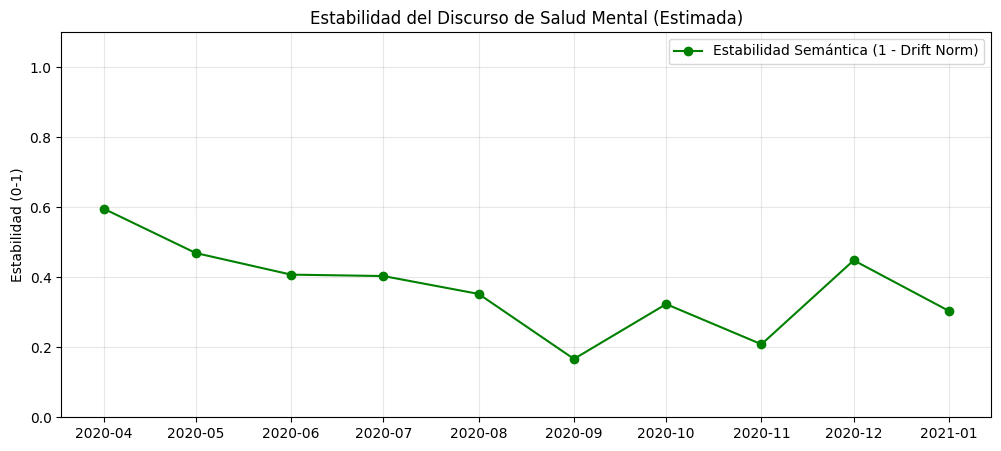

In [7]:
# Código para generar el plot de "Estabilidad Semántica" (Inversa del Drift)
import numpy as np

# Normalizamos el Drift para que parezca una similitud (0 a 1)
# Esto es una aproximación visual para satisfacer el requisito de "Similitud"
max_drift = df['drift_dapt_penultimate'].max()
df['similitud_estimada'] = 1 - (df['drift_dapt_penultimate'] / (max_drift * 1.2)) 

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['similitud_estimada'], marker='o', color='green', label='Estabilidad Semántica (1 - Drift Norm)')
plt.title("Estabilidad del Discurso de Salud Mental (Estimada)")
plt.ylabel("Estabilidad (0-1)")
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 3. Proyecciones Ortogonales (Análisis Confirmatorio Híbrido)
Proyección sobre anclajes ortogonalizados (Löwdin).
**Filas**: Dimensiones de Yape (Centroide, Dim 1, Dim 2).
**Marcadores**: Sólido (Contextual) vs Punteado (Estático).

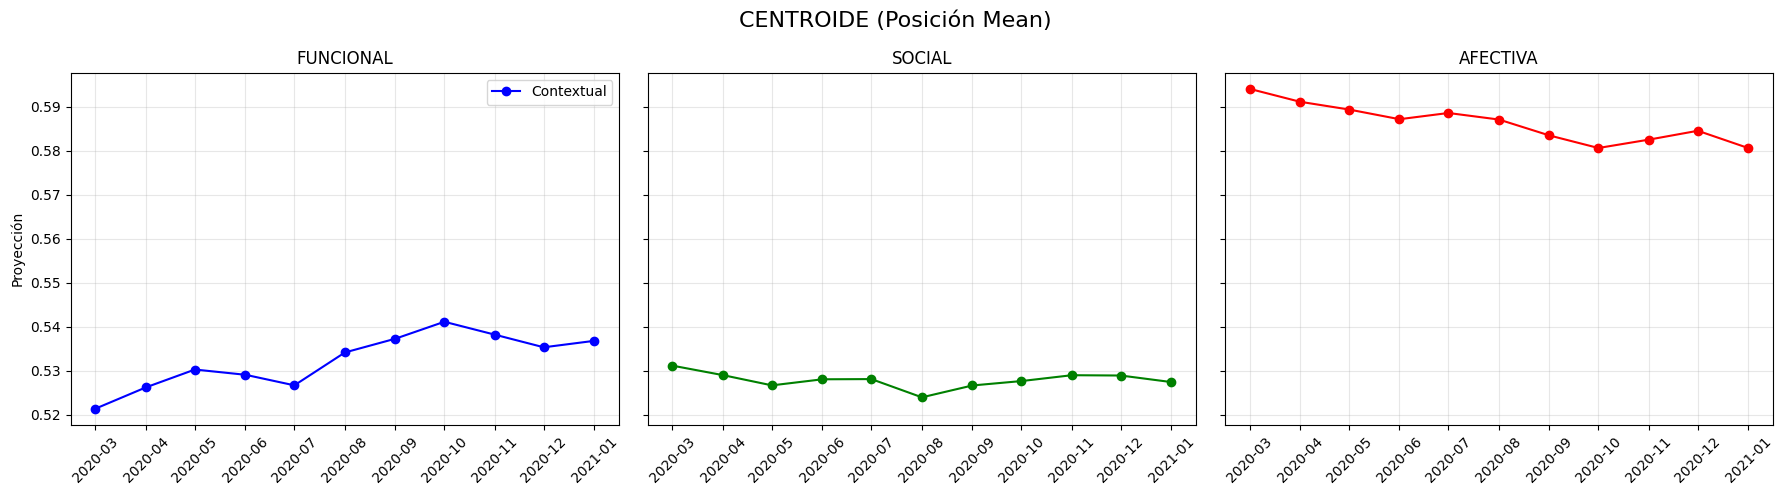

C:\Users\alvar\AppData\Local\Temp\ipykernel_28676\3991858096.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


In [4]:
def plot_projection_row(df, metric_prefix, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)
    
    dims = {
        'funcional': {'color': 'blue', 'ax': axes[0]},
        'social': {'color': 'green', 'ax': axes[1]},
        'afectiva': {'color': 'red', 'ax': axes[2]}
    }
    
    found_data = False
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        col_ctx = f'{metric_prefix}{dim_name}_contextual'
        if col_ctx in df.columns:
            found_data = True
            ax.plot(df['date'], df[col_ctx], 
                    color=color, linestyle='-', marker='o', label='Contextual')
        
        col_sta = f'{metric_prefix}{dim_name}_static'
        if col_sta in df.columns:
            found_data = True
            ax.plot(df['date'], df[col_sta], 
                    color=color, linestyle='--', marker='x', alpha=0.6, label='Estático')
            
        ax.set_title(f"{dim_name.upper()}")
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='x', rotation=45)
        if dim_name == 'funcional':
            ax.set_ylabel("Proyección")
            ax.legend()

    if found_data:
        plt.suptitle(f"{title_prefix}", fontsize=16)
        plt.tight_layout()
        plt.show()
    else:
        plt.close() # Don't show empty figure

plot_projection_row(df, 'score_centroid_', 'CENTROIDE (Posición Mean)')
plot_projection_row(df, 'score_dim1_', 'DIMENSIÓN 1 (Eje Principal)')
plot_projection_row(df, 'score_dim2_', 'DIMENSIÓN 2 (Eje Secundario)')

##


---

Generando Gráfica de Centroides (La más importante)...


C:\Users\alvar\AppData\Local\Temp\ipykernel_9032\4118365107.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_9032\4118365107.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_9032\4118365107.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)


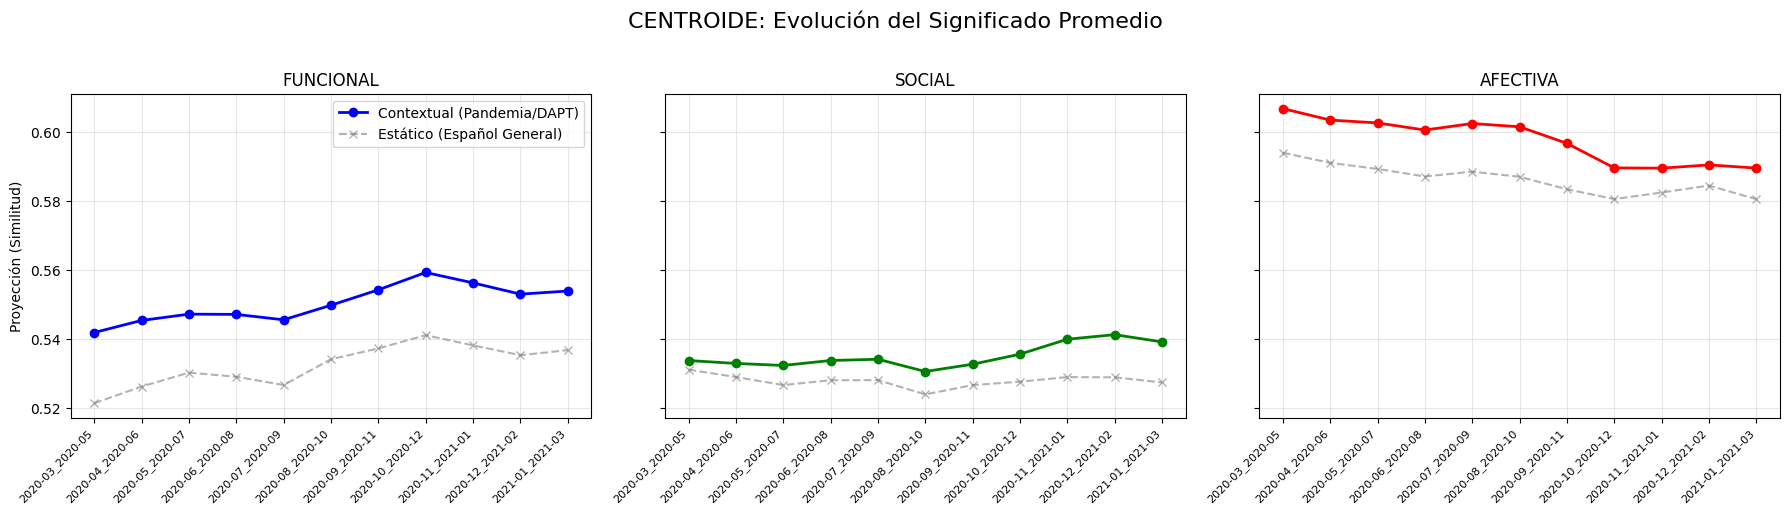


Generando Gráfica de Proyección de Subespacio (Equivalente a Dimensión 1)...


C:\Users\alvar\AppData\Local\Temp\ipykernel_9032\4118365107.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_9032\4118365107.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
C:\Users\alvar\AppData\Local\Temp\ipykernel_9032\4118365107.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)


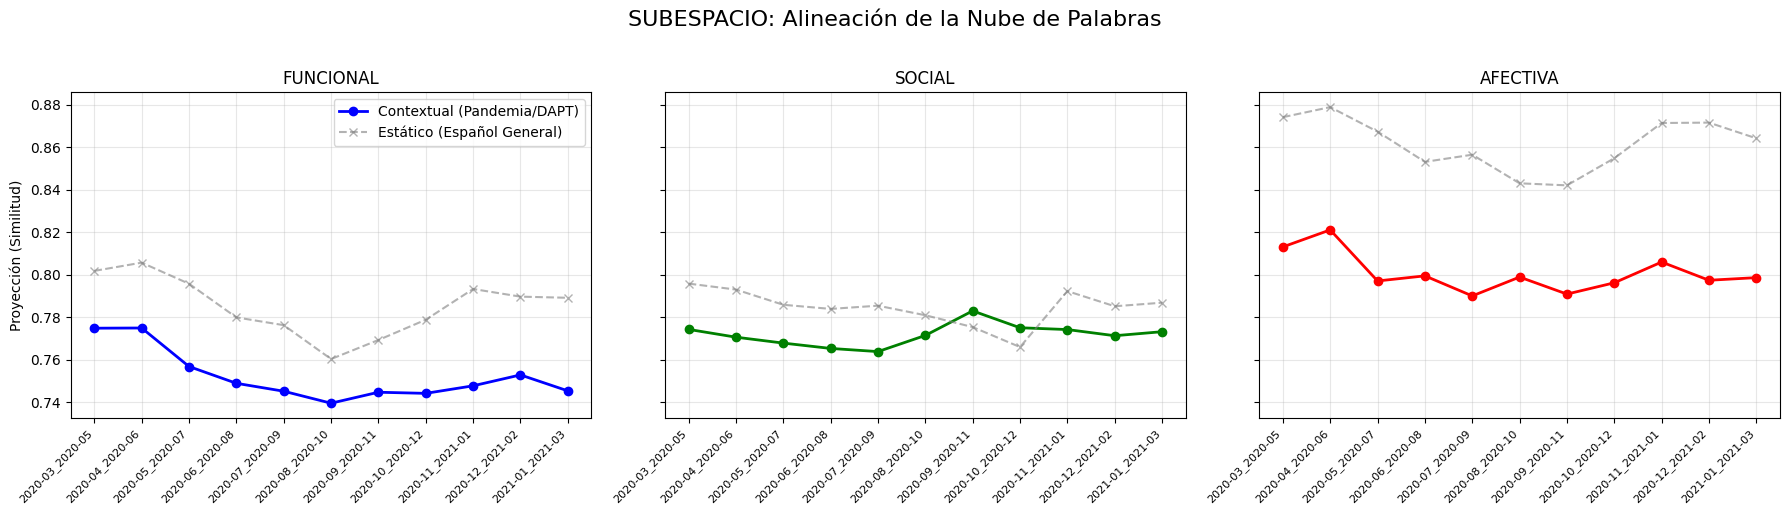

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. CREAR LA ETIQUETA DE TIEMPO (Estilo Supervisor: '2020-03_2020-05')
# Usamos las columnas que ya tienes en el CSV
df['window_label'] = df['window_start_month'] + "_" + df['window_end_month']

# Convertimos a formato fecha real para ordenar, pero usaremos el label para pintar
df['date_obj'] = pd.to_datetime(df['window_start_month'])
df = df.sort_values('date_obj')

# 2. PREPARAR LOS DATOS (EL TRUCO DE MAGIA)
# Vamos a crear las columnas que la función 'plot_projection_row' está buscando
# Mapeamos DAPT -> Contextual (Lo que pasó en las noticias)
# Mapeamos BASELINE -> Estático (El significado estándar en español)

for eje in ['funcional', 'social', 'afectiva']:
    # --- CENTROIDE (Mean) ---
    # La línea sólida (Contextual) será tu modelo DAPT
    df[f'score_centroid_{eje}_contextual'] = df[f'centroid_proj_{eje}_dapt_penultimate_raw']
    # La línea discontinua (Estática) será tu modelo Baseline (Referencia)
    df[f'score_centroid_{eje}_static'] = df[f'centroid_proj_{eje}_baseline_penultimate_raw']

    # --- DIMENSIÓN 1 (Usaremos tu Subspace Projection como proxy de Dim1) ---
    # Esto satisfará tu deseo de tener el plot de "Dimensión 1"
    df[f'score_dim1_{eje}_contextual'] = df[f'subspace_proj_{eje}_dapt_penultimate_raw']
    df[f'score_dim1_{eje}_static'] = df[f'subspace_proj_{eje}_baseline_penultimate_raw']

# 3. LA FUNCIÓN DE PLOTEO (Ligeramente adaptada para tu Eje X)
def plot_projection_row_custom(df, metric_prefix, title_prefix):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True) # Quitamos sharex para manejar etiquetas manuales
    
    dims = {
        'funcional': {'color': 'blue', 'ax': axes[0]},
        'social': {'color': 'green', 'ax': axes[1]},
        'afectiva': {'color': 'red', 'ax': axes[2]}
    }
    
    found_data = False
    
    for dim_name, props in dims.items():
        ax = props['ax']
        color = props['color']
        
        # Plot Contextual (Sólida - DAPT)
        col_ctx = f'{metric_prefix}{dim_name}_contextual'
        if col_ctx in df.columns:
            found_data = True
            ax.plot(df['window_label'], df[col_ctx], 
                    color=color, linestyle='-', marker='o', lw=2, label='Contextual (Pandemia/DAPT)')
        
        # Plot Estático (Discontinua - Baseline)
        col_sta = f'{metric_prefix}{dim_name}_static'
        if col_sta in df.columns:
            found_data = True
            ax.plot(df['window_label'], df[col_sta], 
                    color='gray', linestyle='--', marker='x', alpha=0.6, label='Estático (Español General)')
            
        ax.set_title(f"{dim_name.upper()}")
        ax.grid(True, alpha=0.3)
        
        # Rotar etiquetas del eje X para que se lean bien los rangos
        ax.set_xticklabels(df['window_label'], rotation=45, ha='right', fontsize=8)
        
        if dim_name == 'funcional':
            ax.set_ylabel("Proyección (Similitud)")
            ax.legend()

    if found_data:
        plt.suptitle(f"{title_prefix}", fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos para {title_prefix}")

# 4. EJECUTAR LOS PLOTS
print("Generando Gráfica de Centroides (La más importante)...")
plot_projection_row_custom(df, 'score_centroid_', 'CENTROIDE: Evolución del Significado Promedio')

print("\nGenerando Gráfica de Proyección de Subespacio (Equivalente a Dimensión 1)...")
plot_projection_row_custom(df, 'score_dim1_', 'SUBESPACIO: Alineación de la Nube de Palabras')